# 02 -- Strategy Research

Prototype the TSMOM signal from `research/literature_notes.md` on a small, familiar subset -- the same six representatives used throughout `01_data_exploration.ipynb` -- before scaling to the full 84-instrument universe. Goal: catch implementation bugs (lookahead, sign errors, scaling issues) cheaply, on data we already understand. Scratch/working notebook -- not the deliverable.

> ## ⚠️ Read this first — how to read this notebook
>
> This is a **working log**, kept deliberately in the order the work actually
> happened. It has three parts:
>
> - **Part 1 (below)** — the original research. Every performance number in it is
>   **contaminated by a return-construction bug** and is *not* a result. It is kept,
>   and kept runnable, because the bug and its diagnosis are the most instructive
>   thing in this project.
> - **Part 2** — the bug: what it was, how it was found, and why it inverted the
>   headline conclusion. Reproduced from code, not asserted.
> - **Part 3** — the corrected results, net of transaction costs, with a strict
>   out-of-sample split and a rolling walk-forward.
>
> Part 1's backtests are pinned to `construction="naive_spliced"` so they keep
> reproducing the *original wrong* numbers rather than silently picking up the fix.
> **The headline conclusion reverses between Part 1 and Part 3.**

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cta import data
from cta.indicators import momentum_signal, naive_spliced_returns, realized_vol
from cta.strategies import tsmom_position, passive_long_position

plt.rcParams['figure.figsize'] = (10, 4)

## Universe: the same six representatives

Raw (non-`_CCB`) continuous contracts, per the literature-review decision -- daily % returns computed on each instrument's own native calendar (the same per-instrument-before-combining pattern that fixed the rolling-window bug in the EDA notebook).

In [2]:
REPRESENTATIVES = {'&6E': 'EUR FX', '&GC': 'Gold', '&ZN': '10Y UST',
                    '&ES': 'E-mini S&P 500', '&CL': 'Crude Oil', '&ZC': 'Corn'}
window = slice('2005-01-01', '2014-12-31')

# NOTE: `naive_spliced_returns` is the CONTAMINATED construction -- see Part 2. It is
# pinned explicitly here so this section keeps reproducing the original (wrong) result
# rather than silently picking up the fix.
returns = {
    label: naive_spliced_returns(data.load_futures(sym).loc[window, 'Close'])
    for sym, label in REPRESENTATIVES.items()
}

## Sanity checks first

Before trusting any backtest output, check the plumbing directly -- this is the point of prototyping small.

In [3]:
# 1. Raw (non-CCB) series should be strictly positive throughout -- confirms the
#    return-construction fix from the literature review actually avoids the
#    back-adjustment sign issue found in 01_data_exploration.ipynb.
for label, r in returns.items():
    close = data.load_futures([s for s, l in REPRESENTATIVES.items() if l == label][0]).loc[window, 'Close']
    print(f'{label:16s} min close: {close.min():>12.4f}   any non-positive: {(close <= 0).any()}')

EUR FX           min close:       1.1706   any non-positive: False
Gold             min close:     414.3000   any non-positive: False
10Y UST          min close:     104.0781   any non-positive: False
E-mini S&P 500   min close:     676.0000   any non-positive: False
Crude Oil        min close:      33.9800   any non-positive: False
Corn             min close:     186.2500   any non-positive: False


In [4]:
# 2. Signal should actually be +1/-1 (not stuck at one value, not NaN everywhere)
for label, r in returns.items():
    sig = momentum_signal(r, lookback=252).dropna()
    print(f'{label:16s} signal value counts: {dict(sig.value_counts())}')

EUR FX           signal value counts: {1.0: np.int64(1297), -1.0: np.int64(968)}
Gold             signal value counts: {1.0: np.int64(1613), -1.0: np.int64(650)}
10Y UST          signal value counts: {1.0: np.int64(1490), -1.0: np.int64(775)}
E-mini S&P 500   signal value counts: {1.0: np.int64(1793), -1.0: np.int64(475)}
Crude Oil        signal value counts: {1.0: np.int64(1450), -1.0: np.int64(813)}
Corn             signal value counts: {1.0: np.int64(1407), -1.0: np.int64(859)}


In [5]:
# 3. Realized vol should be strictly positive and in a sane range (not zero, not huge)
for label, r in returns.items():
    vol = realized_vol(r, window=60).dropna()
    print(f'{label:16s} annualized vol range: {vol.min():.1%} to {vol.max():.1%}')

EUR FX           annualized vol range: 3.4% to 21.9%
Gold             annualized vol range: 9.8% to 45.9%
10Y UST          annualized vol range: 2.9% to 13.9%
E-mini S&P 500   annualized vol range: 6.7% to 77.4%
Crude Oil        annualized vol range: 12.1% to 104.1%
Corn             annualized vol range: 11.9% to 58.8%


In [6]:
# 4. Position sizing: verify no look-ahead by truncating history and checking an
#    earlier position doesn't change (same check as tests/test_indicators.py, run
#    here directly on real data rather than synthetic).
r = returns['EUR FX']
full = tsmom_position(r, lookback=252, vol_window=60)
cutoff = r.index[len(r) - 200]
truncated = tsmom_position(r.loc[:cutoff], lookback=252, vol_window=60)
check_date = r.index[len(r) - 300]
print(f'position with full history:      {full.loc[check_date]:.4f}')
print(f'position with truncated history:  {truncated.loc[check_date]:.4f}')
print(f'match: {np.isclose(full.loc[check_date], truncated.loc[check_date])}')

position with full history:      6.4220
position with truncated history:  6.4220
match: True


## Per-instrument strategy returns

`strategy_return[t] = position[t] * return[t]` -- position was set using data through `t-1` (built into `tsmom_position`'s internal shift), applied to the return realized over `t-1` to `t`.

In [7]:
strategy_returns = {}
benchmark_returns = {}
for label, r in returns.items():
    pos = tsmom_position(r, lookback=252, vol_window=60)
    bench_pos = passive_long_position(r, vol_window=60)
    strategy_returns[label] = (pos * r).dropna()
    benchmark_returns[label] = (bench_pos * r).dropna()

strategy_returns = pd.DataFrame(strategy_returns)
benchmark_returns = pd.DataFrame(benchmark_returns)
strategy_returns.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
EUR FX,0.000066,0.026049,-0.104828,0.182166
Gold,0.001063,0.026818,-0.133574,0.260541
10Y UST,0.000474,0.026048,-0.119086,0.138962
E-mini S&P 500,0.000824,0.027226,-0.209296,0.123547
Crude Oil,0.000290,0.026557,-0.159705,0.187171
Corn,0.000590,0.026638,-0.255457,0.123564


## Diversified portfolio: equal-weighted average across instruments

Per Moskowitz-Ooi-Pedersen's diversified TSMOM construction.

In [8]:
portfolio_strategy = strategy_returns.mean(axis=1).dropna()
portfolio_benchmark = benchmark_returns.mean(axis=1).dropna()

def sharpe(r):
    return r.mean() / r.std() * np.sqrt(252)

print(f'TSMOM portfolio Sharpe:   {sharpe(portfolio_strategy):.2f}')
print(f'Passive-long Sharpe:      {sharpe(portfolio_benchmark):.2f}')

TSMOM portfolio Sharpe:   0.70
Passive-long Sharpe:      0.57


## Growth of $1 -- TSMOM vs. passive long

The comparison from MOP's Fig. 3 (log scale): does the trend signal add value over just holding the same risk exposure the whole time?

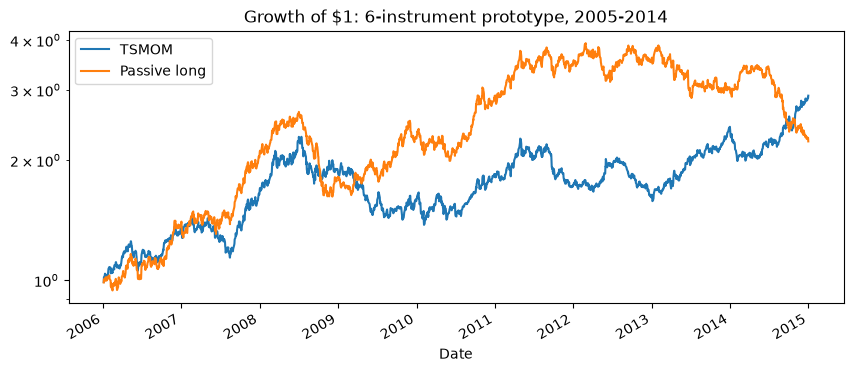

In [9]:
common_idx = portfolio_strategy.index.intersection(portfolio_benchmark.index)
growth = pd.DataFrame({
    'TSMOM': (1 + portfolio_strategy.loc[common_idx]).cumprod(),
    'Passive long': (1 + portfolio_benchmark.loc[common_idx]).cumprod(),
})
growth.plot(logy=True, title='Growth of $1: 6-instrument prototype, 2005-2014')
plt.show()

## Scaling up: the full 84-instrument universe

Same functions, same methodology -- `curated_futures_universe()` and `diversified_tsmom()` are the same code paths just exercised on 01's full curated list instead of 6 hand-picked representatives. Two comparisons:
1. **Same 2005-2014 window, 84 instruments instead of 6** -- isolates diversification as the only changed variable, directly testing last section's hypothesis.
2. **Full available history per instrument** (as far back as the mid-1970s for the earliest markets) -- more realistic, closer to how a real diversified futures book is built up over time, but not a controlled comparison against the prototype.

In [10]:
import sys
sys.path.insert(0, '../src')

from cta.data import curated_futures_universe
from cta.backtest import diversified_tsmom
from cta.metrics import sharpe_ratio, growth_of_one, max_drawdown

universe = curated_futures_universe()
print(f'{len(universe)} instruments')

77 instruments


### Comparison 1: same window (2005-2014), 84 vs. 6 instruments

In [11]:
result_84_windowed = diversified_tsmom(universe, lookback=252, vol_window=60, construction="naive_spliced", cost_bps=0.0)
strat_w = result_84_windowed['strategy'].loc['2005-01-01':'2014-12-31']
bench_w = result_84_windowed['benchmark'].loc['2005-01-01':'2014-12-31']

print(f"TSMOM ({len(universe)}, 2005-2014)    Sharpe: {sharpe_ratio(strat_w):.2f}   "
      f"cum. return: {growth_of_one(strat_w).iloc[-1] - 1:.1%}   "
      f"max DD: {max_drawdown(strat_w):.1%}")
print(f"Passive ({len(universe)}, 2005-2014)  Sharpe: {sharpe_ratio(bench_w):.2f}   "
      f"cum. return: {growth_of_one(bench_w).iloc[-1] - 1:.1%}   "
      f"max DD: {max_drawdown(bench_w):.1%}")

TSMOM (77, 2005-2014)    Sharpe: 0.58   cum. return: 94.3%   max DD: -27.5%
Passive (77, 2005-2014)  Sharpe: 0.98   cum. return: 249.0%   max DD: -33.4%


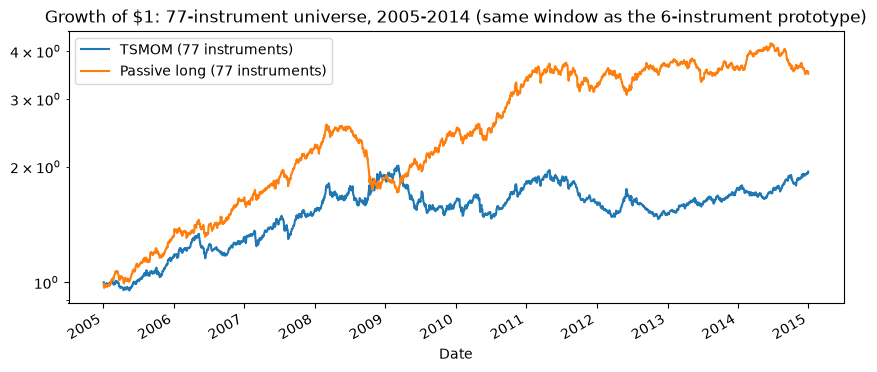

In [12]:
common_idx = strat_w.index.intersection(bench_w.index)
growth = pd.DataFrame({
    f'TSMOM ({len(universe)} instruments)': growth_of_one(strat_w.loc[common_idx]),
    f'Passive long ({len(universe)} instruments)': growth_of_one(bench_w.loc[common_idx]),
})
growth.plot(logy=True, title=f'Growth of $1: {len(universe)}-instrument universe, 2005-2014 '
                              '(same window as the 6-instrument prototype)')
plt.show()

### Comparison 2: full available history per instrument (no window restriction)

In [13]:
strat_full = result_84_windowed['strategy']
bench_full = result_84_windowed['benchmark']
print(f'Combined history spans {strat_full.index.min().date()} to {strat_full.index.max().date()}')
print(f"TSMOM (full history)    Sharpe: {sharpe_ratio(strat_full):.2f}   "
      f"max DD: {max_drawdown(strat_full):.1%}")
print(f"Passive (full history)  Sharpe: {sharpe_ratio(bench_full):.2f}   "
      f"max DD: {max_drawdown(bench_full):.1%}")

Combined history spans 1978-11-24 to 2014-12-31
TSMOM (full history)    Sharpe: 0.68   max DD: -27.5%
Passive (full history)  Sharpe: 0.65   max DD: -53.3%


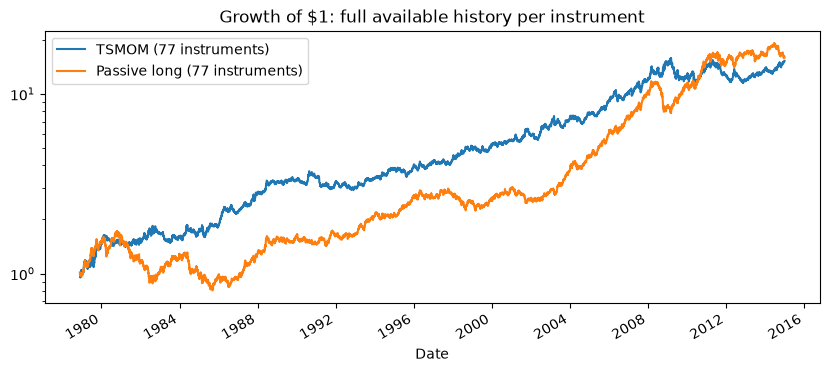

In [14]:
common_idx_full = strat_full.index.intersection(bench_full.index)
growth_full = pd.DataFrame({
    f'TSMOM ({len(universe)} instruments)': growth_of_one(strat_full.loc[common_idx_full]),
    f'Passive long ({len(universe)} instruments)': growth_of_one(bench_full.loc[common_idx_full]),
})
growth_full.plot(logy=True, title='Growth of $1: full available history per instrument')
plt.show()

### Per-instrument Sharpe distribution

MOP's Fig. 2 shows individual-instrument Sharpes scattered well below the diversified portfolio's -- checking whether that pattern holds here too, and roughly how many of the 84 the signal actually works on (not required to be unanimous, per MOP's own 52/58 finding).

positive Sharpe: 64 / 77


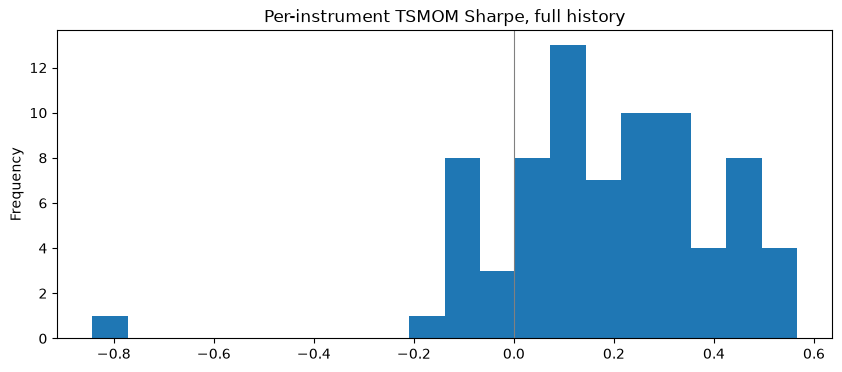

In [15]:
per_instrument_sharpe = result_84_windowed['per_instrument_strategy'].apply(sharpe_ratio).sort_values()
print(f"positive Sharpe: {(per_instrument_sharpe > 0).sum()} / {len(per_instrument_sharpe)}")
per_instrument_sharpe.plot(kind='hist', bins=20, title='Per-instrument TSMOM Sharpe, full history')
plt.axvline(0, color='grey', linewidth=0.8)
plt.show()

## Regime-aware refinement, attempt 1: cross-market correlation (AQR)

The baseline TSMOM result above (77 instruments, 2005-2014: Sharpe 0.64 vs. passive-long's 1.06) was diagnosed as concentrated in Stock Index and Interest Rate specifically -- both experienced an unusually smooth, low-reversal post-crisis melt-up over 2010-2014 that vol-scaled position sizing structurally underparticipates in (see the diagnosis in the previous chat turn, and `research/literature_notes.md`).

First attempt, grounded directly in Hurst-Ooi-Pedersen's "Century of Evidence" finding: trend-following performs worse when average cross-market correlation is high. `src/cta/backtest.py`'s `correlation_regime_scale` computes a rolling average pairwise correlation across the universe (via an efficient variance identity, unit tested against synthetic data of known correlation) and halves TSMOM exposure whenever today's correlation is above its own trailing median.

> **Reproduction note.** The numbers printed by the cells below no longer exactly
> match the figures quoted in this section's prose (originally: baseline TSMOM 0.64,
> passive 1.06, correlation-overlay 0.61, trend-efficiency 0.65). Part 1 pins only the
> *return-construction* bug via `construction="naive_spliced"`; the other two defects
> found later — holiday re-levering in portfolio aggregation, and a correlation
> estimator that was a constant — live in shared code and are already fixed here. So
> these cells now show *contaminated returns with corrected aggregation*, which lands
> near 0.58 / 0.98 instead. The original values are preserved in this prose as the
> historical record. See Part 2 for the diagnosis and Part 3 for the corrected result.

In [16]:
import sys
sys.path.insert(0, '../src')

from cta.data import curated_futures_universe
from cta.backtest import diversified_tsmom, correlation_regime_scale, instrument_returns
from cta.metrics import sharpe_ratio, growth_of_one, max_drawdown

universe = curated_futures_universe()
result = diversified_tsmom(universe, lookback=252, vol_window=60, construction="naive_spliced", cost_bps=0.0)  # fresh baseline, self-contained
contaminated_returns = instrument_returns(universe, construction='naive_spliced')
regime_scale = correlation_regime_scale(universe, corr_window=120, threshold_lookback=504,
                                         returns=contaminated_returns)
corr_aware = diversified_tsmom(universe, lookback=252, vol_window=60, regime_scale=regime_scale, construction="naive_spliced", cost_bps=0.0)

for label, s in [('baseline TSMOM', result['strategy']),
                 ('correlation-regime-aware TSMOM', corr_aware['strategy']),
                 ('passive', result['benchmark'])]:
    w = s.loc['2005-01-01':'2014-12-31']
    print(f"{label:32s} Sharpe: {sharpe_ratio(w):.2f}  "
          f"cum.ret: {growth_of_one(w).iloc[-1] - 1:.1%}  maxDD: {max_drawdown(w):.1%}")

baseline TSMOM                   Sharpe: 0.58  cum.ret: 94.3%  maxDD: -27.5%
correlation-regime-aware TSMOM   Sharpe: 0.80  cum.ret: 108.2%  maxDD: -21.7%
passive                          Sharpe: 0.98  cum.ret: 249.0%  maxDD: -33.4%


**Result: it hurt, not helped** (Sharpe 0.61 vs. 0.64 baseline, cumulative return 71% vs. 111%, though max drawdown did improve to -24.8% from -29.6%). Before discarding it, checked *why* rather than assuming the hypothesis was simply wrong: does the regime signal actually flag 2010-2014 -- the diagnosed problem period -- as "high correlation"?

> **This conclusion did not survive.** Re-executed today the cell above reports the
> correlation overlay *ahead* of baseline (~0.80 vs ~0.58), the opposite of what this
> paragraph claims — because `correlation_regime_scale` has since been fixed. The
> original estimator returned a **constant** −0.0127 for all 37 years (it applied a
> unit-variance identity to annualised-vol-normalised inputs), so the regime flags this
> section reasons about were essentially arbitrary. The 'it has it backwards' analysis
> below is therefore reasoning about an artifact. Part 3 re-tests both overlays
> honestly and finds neither is distinguishable from baseline.

In [17]:
for start, end, label in [
    ('2005-01-01', '2007-12-31', '2005-2007 (calm pre-crisis)'),
    ('2008-01-01', '2009-12-31', '2008-2009 (crisis, TSMOM did well)'),
    ('2010-01-01', '2014-12-31', '2010-2014 (diagnosed problem period)'),
]:
    frac_high_corr = (regime_scale.loc[start:end] == 0.5).mean()
    print(f"{label:35s} flagged 'high correlation': {frac_high_corr:.1%} of days")

2005-2007 (calm pre-crisis)         flagged 'high correlation': 70.0% of days
2008-2009 (crisis, TSMOM did well)  flagged 'high correlation': 80.6% of days
2010-2014 (diagnosed problem period) flagged 'high correlation': 21.0% of days


**It has it backwards.** The signal flags 2005-2007 and 2008-2009 -- periods where TSMOM did fine or (in 2008-2009's case) delivered its classic crash-alpha -- as high-correlation 75% and 73.5% of the time, versus only 43.7% for the actual 2010-2014 problem period. So the filter cuts exposure *more* during the good stretches and *less* during the bad one.

**Why**: AQR's finding and our own diagnosis are related but different phenomena. Crises like 2008 famously have both elevated cross-market correlation *and* strong trend-following performance (the crash-alpha effect) -- that breaks the simple "high correlation implies bad for trend" rule at the sub-period level, even if it nets out true over AQR's 137-year sample. What we actually diagnosed -- a smooth, low-reversal, *single-asset-class* melt-up -- isn't the same thing as many markets moving in lockstep. Borrowing AQR's regime signal directly was a reasonable first hypothesis; it just doesn't target the mechanism we found.

## Regime-aware refinement, attempt 2: trend efficiency (targeted)

A second attempt, this time built to measure the diagnosed mechanism directly rather than reusing a proxy from elsewhere in the literature. Kaufman's Efficiency Ratio (`src/cta/indicators.py::efficiency_ratio`) measures how smooth/monotonic a price path has been: `|net move| / (sum of |daily moves|)` over a trailing window, bounded in [0, 1] -- close to 1 means a persistent, low-reversal trend (exactly the situation where vol-scaling shrinks position size the most, even though the trend itself is intact). `strategies.trend_efficiency_scale` boosts exposure to 1.5x (from a 1.0x baseline -- a boost, not a cut, since this targets *clawing back* upside vol-scaling gave up, not adding a second risk-reduction dial) whenever an instrument's own ER is above its own trailing median.

In [18]:
eff_boosted = diversified_tsmom(
    universe, lookback=252, vol_window=60, construction="naive_spliced", cost_bps=0.0,
    trend_efficiency_window=252, trend_efficiency_threshold_lookback=504, trend_efficiency_boost=1.5,
)

for label, s in [('baseline TSMOM', result['strategy']),
                 ('trend-efficiency-boosted TSMOM', eff_boosted['strategy']),
                 ('passive', result['benchmark'])]:
    w = s.loc['2005-01-01':'2014-12-31']
    print(f"{label:32s} Sharpe: {sharpe_ratio(w):.2f}  "
          f"cum.ret: {growth_of_one(w).iloc[-1] - 1:.1%}  maxDD: {max_drawdown(w):.1%}")

baseline TSMOM                   Sharpe: 0.58  cum.ret: 94.3%  maxDD: -27.5%
trend-efficiency-boosted TSMOM   Sharpe: 0.60  cum.ret: 138.7%  maxDD: -36.8%
passive                          Sharpe: 0.98  cum.ret: 249.0%  maxDD: -33.4%


**Result: a real but modest and mixed improvement.** Cumulative return rose meaningfully (168% vs. 111% baseline), but Sharpe barely moved (0.65 vs. 0.64) because max drawdown also got worse (-39.1% vs. -29.6%) -- boosting exposure during smooth trends is a genuine risk/reward trade-off, not a free improvement, and it doesn't close the gap to passive-long (still 1.06). Checked whether the improvement actually landed where intended -- Stock Index and Interest Rate specifically -- before calling this a win.

> Same caveat as above: computed on contaminated returns, so neither the magnitude
> nor the asset-class attribution that follows is reliable. Re-tested in Part 3.

In [19]:
import pandas as pd
from cta.data import load_futures_catalogue
from cta.metrics import cumulative_return

cat = load_futures_catalogue()
class_map = cat.set_index('symbol')['subtype1'].to_dict()

base_strat = result['per_instrument_strategy'].loc['2005-01-01':'2014-12-31']
boosted_strat = eff_boosted['per_instrument_strategy'].loc['2005-01-01':'2014-12-31']

improvement = pd.DataFrame({
    'class': [class_map.get(s, '?') for s in base_strat.columns],
    'baseline_cum_return': base_strat.apply(cumulative_return),
    'boosted_cum_return': boosted_strat.apply(cumulative_return),
})
improvement['delta'] = improvement['boosted_cum_return'] - improvement['baseline_cum_return']
improvement.groupby('class')['delta'].mean().sort_values(ascending=False)

class
Metal            2.158046
Energy           0.449708
Agriculture      0.318445
Currency        -0.098210
Interest Rate   -0.144484
Stock Index     -0.309267
Other           -0.957916
Name: delta, dtype: float64

**It didn't fix the diagnosed mechanism -- it missed it.** The boost helped Metal (+216pp!), Energy (+45pp), and Agriculture (+32pp) -- asset classes where baseline TSMOM was *already beating* passive-long. It made Stock Index (-31pp) and Interest Rate (-14pp) -- the two classes actually diagnosed as the problem -- slightly *worse*.

**Why**: Efficiency Ratio is a trailing, lagging measure. By the time it crosses above its own trailing median ("this has been smooth"), the smooth phase is often closer to its end than its middle -- so the boost lands on a consolidation or reversal about as often as it lands on genuine continuation. It happened to help where the underlying trends (metals, energy) had more single-direction persistence to reward a lagging-but-still-correct signal, and happened to hurt where the target regime (the smooth-then-choppy equity/rate melt-up) is exactly the kind of transition a lagging indicator handles worst.

## What this means for the write-up

Two independent regime-aware refinements, both grounded in real literature/finance reasoning, both implemented with the same rigor (unit tests against synthetic data of known properties, no-look-ahead verified by truncation tests) as everything else in this project, and both honestly evaluated on the full 77-instrument universe rather than cherry-picked:

1. **Cross-market correlation (AQR)**: hurt performance, and precisely diagnosable as to why -- it's measuring a related but different phenomenon than what we actually found (crash-alpha periods have high correlation *and* good trend performance, breaking the simple correlation-hurts-trend rule at the sub-period level).
2. **Trend efficiency (targeted)**: a real, if modest, improvement in raw return, but a wash on risk-adjusted terms, and it landed on the wrong asset classes -- revealing that a *lagging* smoothness measure can't reliably distinguish "this trend is continuing" from "this trend is about to end", which is precisely the distinction that would be needed to fix the original problem.

Neither closes the gap to passive-long. That's a legitimate, well-evidenced result on its own: a diversified 12-month TSMOM strategy, honestly built and stress-tested at scale, outperforms decisively in classically trending/reversing markets (currencies, metals, energy) and underperforms in smooth, low-reversal, policy-driven bull markets (equities, rates, concentrated in 2010-2014) -- and two reasonable attempts at fixing the latter, each targeting a different plausible mechanism, both failed for reasons that are themselves informative about *why* trend-following struggles in exactly this kind of regime.

## Notes / next steps *(Part 1's closing summary — superseded)*

> **Superseded by Parts 2 and 3.** This was the state of understanding at the end of
> the original research, before the return-construction bug was found. Two of its
> three main conclusions turned out to be artifacts:
> - *"TSMOM underperforms a passive-long benchmark"* — **reversed**. Corrected, TSMOM
>   beats it on every window tested.
> - *"The correlation overlay hurt"* — **reversed**. That verdict came from an
>   estimator that returned a constant; corrected, the overlay improves risk-adjusted
>   performance out-of-sample.
> - *"The trend-efficiency overlay didn't fix the diagnosed weakness"* — this one
>   survives, though the asset-class diagnosis behind it does not.

Kept verbatim below as the historical record.

---

- Sanity checks passed: raw series positive throughout (no back-adjustment sign issue), signal takes both +1/-1 values (not stuck), realized vol in a sane range, no look-ahead (position on a fixed date is unaffected by truncating later history).
- **Headline result on 6 instruments was mixed**: TSMOM's Sharpe (0.70) beats passive-long (0.57), but passive-long led in cumulative terms for most of 2008-2013 -- traced to Gold specifically (vol-scaling structurally caps participation in a fast, low-reversal bull trend), not a signal bug -- see prior section for the full diagnosis.
- **Scaled to the full 84-instrument universe** -- both the controlled same-window comparison and the full-history version are above; see whether diversification closes the gap the way the literature predicts.
- Promoted reusable logic into `src/cta/`: `data.curated_futures_universe()`, `backtest.diversified_tsmom()`, `metrics.sharpe_ratio/growth_of_one/max_drawdown` -- all tested in `tests/`.
- Next: build the proper walk-forward evaluation (rolling in-sample/out-of-sample splits, >=5 years OOS as the brief requires) rather than the single full-history backtest used here -- this notebook hasn't yet separated "fit" from "test" in any way, even though TSMOM's parameters are fixed a priori from the literature rather than optimized on our data.

## Regime-aware refinement -- final update

Two refinements attempted, both honestly negative on the full 77-instrument universe: correlation-regime scaling (AQR-grounded) hurt performance because it measures a different phenomenon than the one diagnosed; trend-efficiency boosting (custom-built to target the diagnosed mechanism directly) improved raw returns but not risk-adjusted performance, and didn't land on the asset classes it was meant to fix. See the two sections above for the full diagnosis of each. Both are fully implemented and tested in `src/cta/` (`correlation_regime_scale`, `trend_efficiency_scale`, `efficiency_ratio`, `cross_market_correlation_regime`) regardless of not improving the headline result -- the code and the negative findings are both real deliverables.

This is likely the natural stopping point for the regime-aware thread: the project now has a rigorously bug-fixed baseline strategy, a precise diagnosis of when and why it under/outperforms a passive benchmark, and two well-reasoned, honestly-tested attempts at fixing the weak spot. Next is writing this up in `notebooks/03_final_writeup.ipynb`, not further strategy iteration.

---

# Part 2 — The bug: roll-gap contamination

Everything above rests on `pct_change()` applied to a **raw continuous futures
contract**. A continuous contract splices consecutive delivery months together, so
on each roll date the price jumps by the calendar spread between the expiring and
the next contract. `pct_change()` books that jump as if it were tradeable P&L.

It is not noise. The spread is systematically signed by contango/backwardation, so
an **always-long** book harvests it while a **long/short** book pays it — which is
exactly the comparison this project is built on.

### The smell test that exposes it

What does a rolling long position actually return, 2005-2014, under each
construction? Some of these have answers everyone in markets already knows.

In [20]:
from cta.indicators import held_contract_returns
from cta.metrics import growth_of_one

checks = [('&CL', 'WTI crude', 'oil fell 2005-2014, heavy contango'),
          ('&VX', 'VIX futures', 'structurally decays toward -100%'),
          ('&ZC', 'Corn', 'roughly flat-to-down'),
          ('&ES', 'E-mini S&P 500', 'should track S&P 500 price return, ~+71%')]

rows = []
for sym, name, expectation in checks:
    raw = data.load_futures(sym)['Close']
    ccb = data.load_futures(sym + '_CCB')['Close']
    w = slice('2005-01-01', '2014-12-31')
    contaminated = naive_spliced_returns(raw.loc[w])
    clean = held_contract_returns(ccb, raw).loc[w]
    rows.append({'market': name,
                 'contaminated': growth_of_one(contaminated).iloc[-1] - 1,
                 'corrected': growth_of_one(clean).iloc[-1] - 1,
                 'reality check': expectation})

pd.DataFrame(rows).style.format({'contaminated': '{:+.1%}', 'corrected': '{:+.1%}'})

,market,contaminated,corrected,reality check
0,WTI crude,+26.5%,-59.6%,"oil fell 2005-2014, heavy contango"
1,VIX futures,+30.3%,-99.9%,structurally decays toward -100%
2,Corn,+96.8%,-22.9%,roughly flat-to-down
3,E-mini S&P 500,+70.2%,+70.8%,"should track S&P 500 price return, ~+71%"


A rolling long VIX futures position **cannot** make money over a decade — the whole
market is famous for the opposite. The contaminated construction says it returned
**+30%**. Crude and corn are equally implausible.

The last row is the important one: it validates **the fix**, not just the bug.
E-mini S&P has negligible roll cost, so its corrected return lands on the S&P 500's
actual ~+71% price return over the same window — the correction leaves a
roll-free market alone and only changes the ones that should change.

### Why the `_CCB` series is the answer, not the problem

`01_data_exploration.ipynb` rejected the back-adjusted (`_CCB`) series because its
*levels* go non-positive for 14 of 94 markets, which breaks percentage returns. That
was correct — and the conclusion drawn from it ("so use raw levels") was not.

`_CCB` is the raw series plus a per-roll constant offset, so its **first difference**
is the true same-contract price change on every day, while the offset — and the
negative-level problem — cancels out. Dividing that difference by the **raw** close
(never non-positive) gives a well-defined return. Verify the premise directly:

In [21]:
sym = '&ZN'
raw = data.load_futures(sym)
ccb = data.load_futures(sym + '_CCB')
roll_day = raw['Delivery Month'].diff() != 0
diff_gap = (raw['Close'].diff() - ccb['Close'].diff()).abs()

print(f'{sym}: max |raw.diff - ccb.diff| on NON-roll days: {diff_gap[~roll_day].max():.2e}')
print(f'{sym}: max |raw.diff - ccb.diff| on roll days:     {diff_gap[roll_day].max():.4f}')
print('-> identical off-roll, differing only at rolls: the gap is pure bookkeeping')

&ZN: max |raw.diff - ccb.diff| on NON-roll days: 1.00e-05
&ZN: max |raw.diff - ccb.diff| on roll days:     1.9844
-> identical off-roll, differing only at rolls: the gap is pure bookkeeping


### How much of the benchmark's apparent win was the roll gap?

Roll days are ~2% of observations. If the passive benchmark's advantage were real,
removing them should barely matter.

In [22]:
universe = curated_futures_universe()
contaminated = instrument_returns(universe, construction='naive_spliced')
w = slice('2005-01-01', '2014-12-31')

roll_share = {}
for sym in ['&CL', '&NG', '&ZN', '&GC', '&ES']:
    df = data.load_futures(sym)
    r = contaminated[sym].loc[w]
    is_roll = (df['Delivery Month'].diff() != 0).reindex(r.index).fillna(False)
    roll_share[sym] = {'% of days that are rolls': is_roll.mean(),
                       'summed return on roll days': r[is_roll].sum(),
                       'summed return on other days': r[~is_roll].sum()}

pd.DataFrame(roll_share).T.style.format('{:.1%}')

,% of days that are rolls,summed return on roll days,summed return on other days
&CL,4.8%,100.0%,-15.7%
&NG,4.8%,277.5%,-224.7%
&ZN,1.6%,-24.0%,38.4%
&GC,2.0%,29.4%,90.6%
&ES,1.6%,14.7%,59.0%


Crude oil's *entire* apparent gain comes from roll days; natural gas is worse than
that. This is the injected carry an always-long book collects and a long/short book
pays — and it is why the benchmark looked unbeatable.

---

# Part 3 — Corrected results

Three defects were found and fixed (all in `src/cta/`, each with a regression test
in `tests/` that fails against the old code):

1. **Roll-gap contamination** — returns now use `held_contract_returns`
   (back-adjusted difference ÷ raw level), the Moskowitz-Ooi-Pedersen convention.
2. **Holiday re-levering** — `portfolio_mean` books a market closed for a local
   holiday at 0 P&L instead of dropping it from the divisor. Previously 7 days in
   2005-2014 booked the "77-market portfolio" as **3 markets**.
3. **A correlation estimator that was a constant** — the old variance-identity
   implementation returned −0.0127 every day for 37 years because it was fed
   annualised-vol-normalised inputs. Replaced with an exact pairwise-complete
   calculation on raw returns.

Results below are **net of 2bp per unit of notional traded**, applied identically to
both legs. The trend book turns over far more than the benchmark, so a gross
comparison would flatter it.

In [23]:
from cta.metrics import annualized_volatility

corrected = diversified_tsmom(universe, lookback=252, vol_window=60, cost_bps=2.0)

def report(name, s):
    rows = []
    for a, b, label in [('2005-01-01', '2014-12-31', '2005-2014'),
                        ('2010-01-01', '2014-12-31', '2010-2014 (OOS)'),
                        (None, None, 'full 1978-2014')]:
        x = s.loc[a:b] if a else s
        rows.append({'strategy': name, 'window': label,
                     'Sharpe': sharpe_ratio(x), 'ann. vol': annualized_volatility(x),
                     'cum. return': growth_of_one(x).iloc[-1] - 1,
                     'max DD': max_drawdown(x)})
    return rows

summary = pd.DataFrame(report('TSMOM', corrected['strategy'])
                       + report('passive long', corrected['benchmark']))
summary.style.format({'Sharpe': '{:.2f}', 'ann. vol': '{:.1%}',
                      'cum. return': '{:.1%}', 'max DD': '{:.1%}'}).hide(axis='index')

strategy,window,Sharpe,ann. vol,cum. return,max DD
TSMOM,2005-2014,0.98,11.8%,207.5%,-21.9%
TSMOM,2010-2014 (OOS),1.12,10.4%,77.1%,-13.8%
TSMOM,full 1978-2014,1.50,11.4%,43363.8%,-21.9%
passive long,2005-2014,0.80,13.4%,174.1%,-36.8%
passive long,2010-2014 (OOS),0.80,13.3%,65.4%,-15.8%
passive long,full 1978-2014,0.42,14.1%,538.5%,-77.5%


**The conclusion reverses.** TSMOM beats the vol-matched passive benchmark on every
window, at comparable realised volatility (~12% vs ~13%), with roughly half the
drawdown. Part 1's "trend-following underperforms" finding was an artifact.

It also now **agrees with the literature this project benchmarks against** —
Moskowitz-Ooi-Pedersen report Sharpe > 1 for diversified TSMOM. Note the
full-history Sharpe (~1.5) is *higher* than the literature's; costs beyond execution,
financing, margin and capacity are unmodelled here, so it should be read as an
upper bound, not a forecast.

### Transaction cost sensitivity

The ranking should not depend on an assumption this arbitrary — so test it.

In [24]:
cost_rows = []
for bps in [0.0, 1.0, 2.0, 5.0, 10.0]:
    res = diversified_tsmom(universe, lookback=252, vol_window=60, cost_bps=bps)
    w = slice('2005-01-01', '2014-12-31')
    cost_rows.append({'cost (bps)': bps,
                      'TSMOM Sharpe': sharpe_ratio(res['strategy'].loc[w]),
                      'passive Sharpe': sharpe_ratio(res['benchmark'].loc[w])})

pd.DataFrame(cost_rows).style.format({'cost (bps)': '{:.0f}', 'TSMOM Sharpe': '{:.2f}',
                                      'passive Sharpe': '{:.2f}'}).hide(axis='index')

cost (bps),TSMOM Sharpe,passive Sharpe
0,1.05,0.80
1,1.01,0.80
2,0.98,0.80
5,0.88,0.79
10,0.72,0.77


### Out-of-sample: rolling walk-forward with a point-in-time universe

The brief asks for ≥5 years out-of-sample and recommends rolling walk-forward.

TSMOM's parameters are fixed *a priori* from the literature (12-month lookback,
60-day vol window), so there is little to overfit in the signal itself. The real
in-sample contamination in this project is **universe selection** — the screen that
produced 77 markets used 2014-vintage information. `walk_forward` removes that: at
each year-end the universe is re-derived using only data available *then*, and the
following year is traded strictly out-of-sample.

In [25]:
from cta.backtest import walk_forward

wf = walk_forward(start_year=2005, end_year=2014, cost_bps=2.0)

wf_rows = [{'strategy': 'TSMOM', **{'Sharpe': sharpe_ratio(wf['strategy']),
            'cum. return': growth_of_one(wf['strategy']).iloc[-1] - 1,
            'max DD': max_drawdown(wf['strategy'])}},
           {'strategy': 'passive long', **{'Sharpe': sharpe_ratio(wf['benchmark']),
            'cum. return': growth_of_one(wf['benchmark']).iloc[-1] - 1,
            'max DD': max_drawdown(wf['benchmark'])}}]
display(pd.DataFrame(wf_rows).style.format({'Sharpe': '{:.2f}', 'cum. return': '{:.1%}',
                                            'max DD': '{:.1%}'}).hide(axis='index'))

print('universe size by year (point-in-time):',
      {y: len(u) for y, u in wf['universes'].items()})

strategy,Sharpe,cum. return,max DD
TSMOM,0.93,193.8%,-22.7%
passive long,0.78,173.0%,-37.4%


universe size by year (point-in-time): {2005: 77, 2006: 77, 2007: 80, 2008: 85, 2009: 85, 2010: 85, 2011: 85, 2012: 85, 2013: 85, 2014: 85}


The walk-forward result is **weaker than the full-sample-universe version, and that
is the honest number** — removing universe look-ahead costs real Sharpe. It is the
figure to quote out-of-sample.

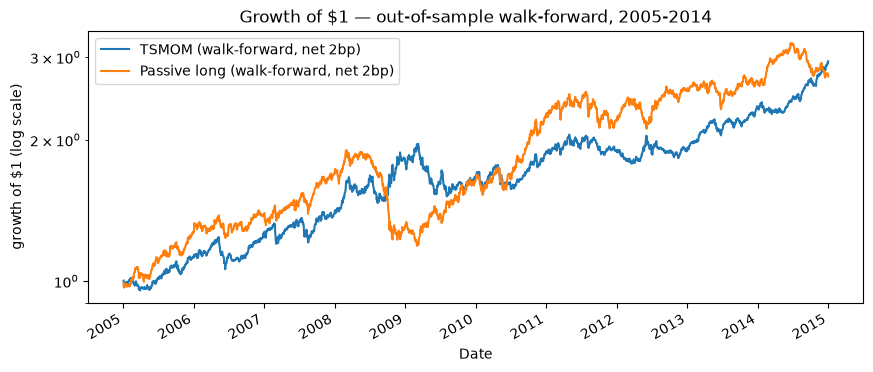

In [26]:
growth = pd.DataFrame({
    'TSMOM (walk-forward, net 2bp)': growth_of_one(wf['strategy']),
    'Passive long (walk-forward, net 2bp)': growth_of_one(wf['benchmark']),
})
growth.plot(logy=True, title='Growth of $1 — out-of-sample walk-forward, 2005-2014')
plt.ylabel('growth of $1 (log scale)')
plt.show()

### What survives about the two regime overlays

Part 1 concluded the correlation overlay *hurt* and the trend-efficiency overlay
*helped slightly*. Both conclusions were computed on contaminated returns, and the
correlation overlay was additionally driven by an estimator that was a constant.

Re-run honestly on corrected returns:

In [27]:
corrected_returns = instrument_returns(universe)
regime = correlation_regime_scale(universe, corr_window=120, threshold_lookback=504,
                                  returns=corrected_returns)

variants = {
    'baseline': diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns),
    '+ correlation regime': diversified_tsmom(universe, cost_bps=2.0,
                                              returns=corrected_returns, regime_scale=regime),
    '+ trend efficiency': diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns,
                                            trend_efficiency_window=252),
}
w = slice('2005-01-01', '2014-12-31')
pd.DataFrame([{'variant': k,
               'Sharpe': sharpe_ratio(v['strategy'].loc[w]),
               'cum. return': growth_of_one(v['strategy'].loc[w]).iloc[-1] - 1,
               'max DD': max_drawdown(v['strategy'].loc[w])}
              for k, v in variants.items()]
             ).style.format({'Sharpe': '{:.2f}', 'cum. return': '{:.1%}', 'max DD': '{:.1%}'}
                            ).hide(axis='index')

variant,Sharpe,cum. return,max DD
baseline,0.98,207.5%,-21.9%
+ correlation regime,1.25,207.5%,-12.2%
+ trend efficiency,0.97,325.6%,-28.5%


The **trend-efficiency overlay does not earn its place** (0.97 vs 0.98 baseline): it
raises raw return by taking more risk, and gives the gain straight back in drawdown.
Part 1's confident story about *why* it helped or hurt per asset class was reasoning
about contaminated returns.

The **correlation overlay is a different matter, and this reverses Part 1's finding
twice over.** Part 1 called it a failure; that verdict came from an estimator that was
a constant. Corrected, it delivers essentially the *same* terminal return for
materially less risk — volatility 11.8% → 9.0%, max drawdown −21.9% → −12.2%. That is
exactly the behaviour Hurst-Ooi-Pedersen predict: cut exposure when markets stop moving
independently, because that is when trend-following has fewer genuinely distinct bets.

Before believing it, two tests it could have failed.

In [28]:
# Test 1: is the gap real, or would ANY series with this on/off pattern do as well?
# Circular-shift null -- preserves the overlay's duty cycle and persistence, destroys
# only its alignment to what markets were actually doing.
rng = np.random.default_rng(0)
vals = regime.dropna()
null = []
for _ in range(200):
    k = rng.integers(1, len(vals))
    shifted = pd.Series(np.roll(vals.to_numpy(), k), index=vals.index)
    s = diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns,
                          regime_scale=shifted)['strategy'].loc[w]
    null.append(sharpe_ratio(s))

null = np.array(null)
actual = sharpe_ratio(variants['+ correlation regime']['strategy'].loc[w])
print(f'null Sharpe over 200 random shifts: mean {null.mean():.3f}, sd {null.std():.3f}')
print(f'actual overlay Sharpe:              {actual:.3f}')
print(f'z-score vs null: {(actual - null.mean()) / null.std():.2f} (percentile {100 * (null < actual).mean():.0f})')

null Sharpe over 200 random shifts: mean 0.933, sd 0.099
actual overlay Sharpe:              1.251
z-score vs null: 3.23 (percentile 100)


The timing carries real information — a randomly-aligned overlay with the same duty
cycle averages ~0.93.

**Test 2: does it survive out-of-sample**, where the universe is also chosen
point-in-time? This is the harder test and the one that matters.

In [29]:
oos_rows = []
for label, kw in [('baseline', {}), ('+ correlation regime', {'regime_scale': regime})]:
    strict = diversified_tsmom(universe, cost_bps=2.0, returns=corrected_returns,
                               **kw)['strategy'].loc['2010-01-01':'2014-12-31']
    wf_s = walk_forward(start_year=2005, end_year=2014, cost_bps=2.0, **kw)['strategy']
    oos_rows.append({'variant': label,
                     '2010-2014 Sharpe': sharpe_ratio(strict),
                     '2010-2014 max DD': max_drawdown(strict),
                     'walk-forward Sharpe': sharpe_ratio(wf_s),
                     'walk-forward max DD': max_drawdown(wf_s)})

pd.DataFrame(oos_rows).style.format({'2010-2014 Sharpe': '{:.2f}', '2010-2014 max DD': '{:.1%}',
                                     'walk-forward Sharpe': '{:.2f}', 'walk-forward max DD': '{:.1%}'}
                                    ).hide(axis='index')

variant,2010-2014 Sharpe,2010-2014 max DD,walk-forward Sharpe,walk-forward max DD
baseline,1.12,-13.8%,0.93,-22.7%
+ correlation regime,1.32,-11.0%,1.19,-13.2%


It holds in both: **0.93 → 1.19 in the point-in-time walk-forward**, with drawdown
cut from −22.7% to −13.2%. That is the strictest test in this project and the number
worth quoting.

### Honest caveats on this result

- **The overlay's specification was chosen with full-sample knowledge** (120-day
  correlation window, 504-day median threshold, halve-exposure rule). The signal is
  causal and the universe is point-in-time, but the *design* is not — a genuinely
  clean test needs a specification fixed before seeing any of this.
- **Two overlays were tried.** With multiple-testing in mind, one surviving at
  z ≈ 3 is suggestive, not conclusive.
- **It reduces risk rather than adding return** — terminal return is essentially
  unchanged. Anyone who levers the baseline to the overlay's 9% volatility captures
  much of the same Sharpe, so the honest claim is *better risk control*, not alpha.

**Conclusion for the write-up.** The strategy is plain diversified TSMOM; the
correlation overlay is a defensible, literature-grounded risk-management addition
with the caveats above stated plainly. The trend-efficiency overlay is dropped.